# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Barbara Chylinska
* Username: bachylinska
* Student number: s6480640
* Group (AS1, etc.): AS5

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

/tmp/ipykernel_3249403/1622298013.py:17: RuntimeWarning: divide by zero encountered in divide
  v=((G.value*2*10**10*M_sun.value)/(np.array(radius)*kpc.value))**0.5/1000


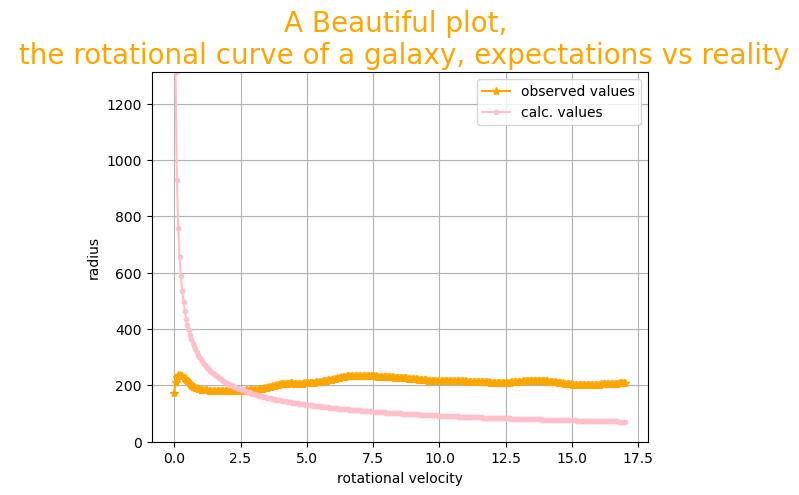

In [26]:
import numpy as np
from astropy.constants import G, M_sun, kpc

f = open("rotcur.dat", 'r')
radius = np.array([])
rot_vel = np.array([])



for dataline in f:
    if not dataline.startswith('#'):
        line = np.fromstring(dataline, sep=' ')  # Space is the separator
        radius = np.append(radius, line[0])
        rot_vel = np.append(rot_vel, line[1])
f.close()

v=((G.value*2*10**10*M_sun.value)/(np.array(radius)*kpc.value))**0.5/1000

np.savetxt("/Users/users/bachylinska/PROGNUM-repo/task5/keplerian_curve.txt",v)
kap=np.loadtxt("/Users/users/bachylinska/PROGNUM-repo/task5/keplerian_curve.txt")


from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt

fig = figure()
frame = fig.add_subplot(1,1,1)  
frame.set_ylim(0,np.max(kap[1:]))
#frame.set_ylim(0,np.max(kap))
frame.plot(radius, rot_vel, marker='*',color='orange',label='observed values')
frame.plot(radius, kap, marker='.',color='pink',label='calc. values')
frame.grid()
plt.legend()
plt.title('A Beautiful plot, \n the rotational curve of a galaxy, expectations vs reality',size=20,color='orange')
plt.xlabel('rotational velocity')
plt.ylabel('radius')

show()




### 

In [2]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

1.0163069845484567
-0.04738674524332681


(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 5.000e+00,
        2.000e+00, 4.000e+00, 1.300e+01, 2.300e+01, 4.600e+01, 9.400e+01,
        1.680e+02, 2.420e+02, 3.530e+02, 5.150e+02, 8.050e+02, 1.051e+03,
        1.508e+03, 1.936e+03, 2.420e+03, 2.915e+03, 3.552e+03, 3.795e+03,
        4.141e+03, 4.492e+03, 4.578e+03, 4.348e+03, 4.201e+03, 3.864e+03,
        3.451e+03, 2.844e+03, 2.367e+03, 1.853e+03, 1.347e+03, 9.990e+02,
        7.050e+02, 4.940e+02, 3.530e+02, 2.310e+02, 1.240e+02, 7.600e+01,
        3.700e+01, 2.500e+01, 1.200e+01, 6.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 1.000e+00]),
 array([-5.01472965, -4.82458345, -4.63443725, -4.44429105, -4.25414485,
        -4.06399865, -3.87385245, -3.68370626, -3.49356006, -3.30341386,
        -3.11326766, -2.92312146, -2.73297526, -2.54282906, -2.35268286,
        -2.16253666, -1.97239046, -1.78224426, -1.59209806, -1.40195186,
        -1.21180566, -1.02165946, -0.83151326, -0.64136707, -0.45122087,
        -0.

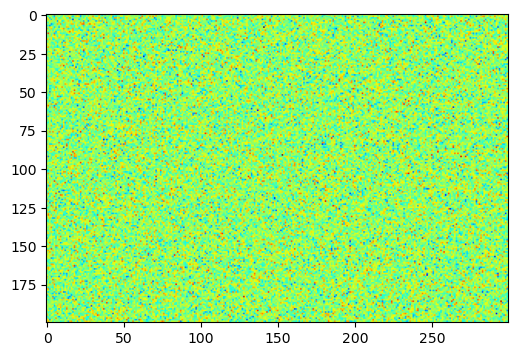

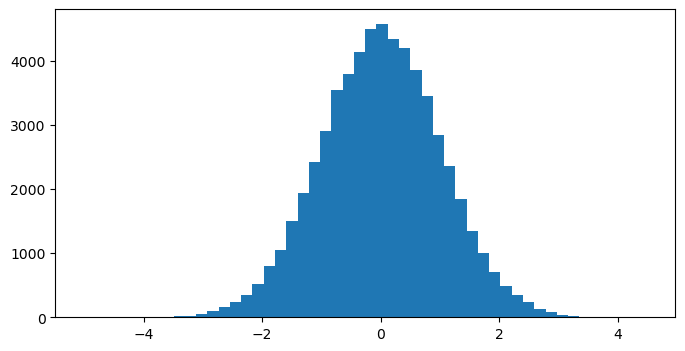

In [97]:
import numpy as np
import matplotlib.pyplot as plt

dat=np.random.normal(0,1,(200,300))
plt.figure(figsize=(8, 4))
plt.imshow(dat,cmap='jet')
sam=dat[90:120,40:70]

print(np.std(sam))
print(np.mean(sam))

#as expected, roughly mean=0 and dev = 1

plt.figure(figsize=(8, 4))
plt.hist(np.ndarray.flatten(dat),50)

#roughly looks like the standard normal distribution

In [4]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

In [6]:
from matplotlib.patches import Ellipse
from scipy.constants import pi

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major & gt ;= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse

#copied from brightspace, doesnt seem to work

SyntaxError: invalid syntax (780986721.py, line 14)

18.84955592153876
15.865437575563961
width :4.0, height: 6.0, angle:0


(-20.0, 20.0)

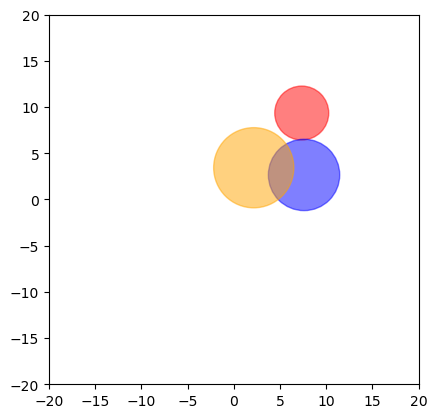

In [1]:
from matplotlib.patches import Ellipse
from scipy.constants import pi
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show
import numpy as np

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        # We use the (sort of) astronomical angle where 'angle' defines)
        # the position angle of the major axis of a ring projected onto the sky
        # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
        # the north direction on the sky and the major axis of the receding half of the
        # galaxy (Rots 1975, astron, astrophys 45, 43).
        # Here we assume (!) north is in the positive Y direction.
        # If not, you need to correct the angle for the rotation of the image.
        # Parameter 'position_angle' enters in degrees
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        
        super().__init__(XY, width, height, angle=angle_mpl, **args)
    def area(self):
        semi_major=self.width*0.5
        semi_minor=self.height*0.5
        area = pi*semi_major*semi_minor
        return area
    def perimeter(self):
        semi_major=self.width*0.5
        semi_minor=self.height*0.5
        p=pi*(3*(semi_major+semi_minor)-((3*semi_major+semi_minor)*(semi_major+3*semi_minor))**0.5)
        return p
    def str(self):
        return(f"width :{self.width}, height: {self.height}, angle:{self.angle}")
        

ell= AstroEllipse(0,0,3,2,0)  
ell2= Ellipse((0,0),3,2)  
print(float(ell.area()))
print(float(ell.perimeter()))
print(ell.str())

class MyCircle(AstroEllipse): 
    def __init__(self, center, radius, **args):
        x,y=center
        rad=radius
        super().__init__(x,y,radius,radius,0 ,**args)

x1,y1,x2,y2,x3,y3,r1,r2,r3=np.random.random(size=9)*10
circ1= MyCircle((x1,y1),r1,alpha=0.5,color='r')
circ2= MyCircle((x2,y2),r2,alpha=0.5,color='b')
circ3= MyCircle((x3,y3),r3,alpha=0.5,color='orange')
#print((circ1))
fig = figure()
frame = fig.add_subplot(1,1,1, aspect=1)
frame.add_patch(circ1)
frame.add_patch(circ2)
frame.add_patch(circ3)
frame.set_xlim(-20,20)    # Limits are not automatically adjusted when patches are used
frame.set_ylim(-20,20)

In [28]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

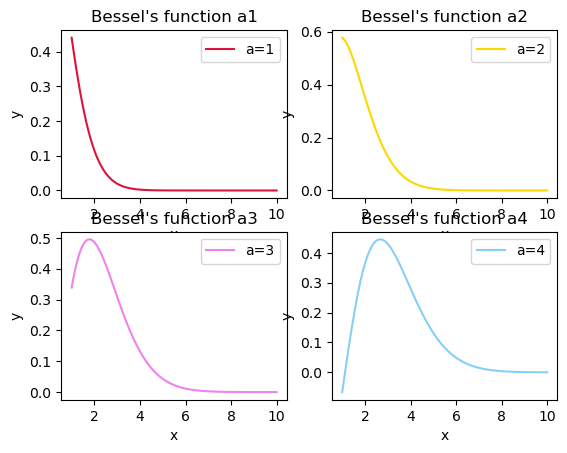

In [100]:
from scipy.special import jv
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()

x=np.linspace(1,10,100)
y1=np.array(jv(x,1))
y2=np.array(jv(x,2))
y3=np.array(jv(x,3))
y4=np.array(jv(x,4))

m=[['a1','a2'],
   ['a3','a4']]



ax_dict=fig.subplot_mosaic(m,)
ax_dict['a1'].plot(x,y1,color='crimson',label='a=1')
ax_dict['a2'].plot(x,y2,color='gold',label='a=2')
ax_dict['a3'].plot(x,y3,color='violet',label='a=3')
ax_dict['a4'].plot(x,y4,color='lightskyblue',label='a=4')

for n in np.ndarray.flatten(np.array(m)):
    ax_dict[n].legend()
    ax_dict[n].set_title(f"Bessel's function {n}")
    ax_dict[n].set_xlabel('x')
    ax_dict[n].set_ylabel('y')



In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

[2094.75, 2320.87, 1224.9, 872.13, 432.2, 751, 1410, 2700, 5292, 2550, 5253, 2419, 2158]


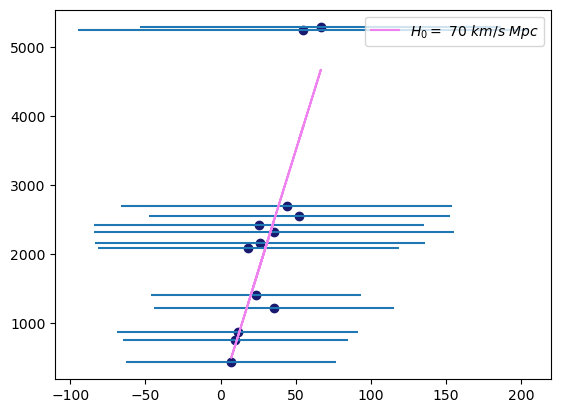

In [11]:
from scipy.special import jv
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
d=np.array(data[::4])
v=data[1::4]
erd=data[2::4]
erv=data[3::4]

h0= 70


print(v)

fig = plt.figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(d,v,color='midnightblue')
frame.errorbar(d,v,erd,erv, fmt='none')
frame.plot(d,h0*d,color='violet', label = '$H_0 = \ 70 \ km/s \ Mpc$')
plt.legend()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")